# Flying Home for Christmas: An Unexpected Optimization Problem!

Have you ever wondered what selecting Christmas presents for the family might have in common with network resource allocation? It turns out that both tasks can be modelled as the same kind of optimisation problem, namely multi-choice multi-
dimensional 0-1 knapsack problem (MMKP) which happens to be [NP-hard](https://doi.org/10.1016/j.cie.2010.12.001). 

One of the problems that I dealt with in my PhD thesis was resource allocation for adaptive multimedia services in case of congestion. Since services supported multiple configurations, each with differnt utility and different resource requirements, the idea was to pick a suitable configuration for every active session such that the total utility is maximised while taking network resource constraints (e.g., total available bandwiths) into account. Back in the days, I started playing with it by doing pure mathematical modelling in Wolfram Mathematica, resulting in my first research [paper](https://doi.org/10.1109/PIMRC.2010.5671784) (full text available [here](https://www.ieee.hr/images/50010415/PIMRC_2010.pdf)). Already then it was evident that finding the optimal solution might quickly become quite time-consuming and that alternative approaches need to be considered for real-time scenarios.

Although picking the right present from every family member might not be as mission-critical as resource reallocation in a mobile network cell in case of congestion (to which my nephews and nieces probably wouldn't agree), allowing just five options for each family member already results in a combinatorial explosion and long execution time if using a naive algorithmic approach. Let's have a look.

I prepared a table with ideas for presents for my family back at home, together with their volumes, weights, prices, and expected utility values (mostly I'm right, but that Pokedex for _Nephew 2_ was a major flop!). While some of these presents already happened, others are just ideas, so please don't share this page with my family! The problem seems simple: pick one present for each family member, such that the total utility of all presents is maximised, while making sure that they don't surpass the volume and weight of my checked luggage. Theoretically I could also impose the limit on total price, but let's be nice for the start.

So, here are the possible presents:

In [1]:
import pandas as pd
presents = pd.read_csv('presents.csv')
presents

,Person,Present,Utility,Volume_L,Weight_kg,Price_CHF
0,Mum,Perfume,10.0,1.12,0.05,100
1,Mum,Book1,8.0,1.60,0.50,22
2,Mum,Sprüngli Chocolate,9.0,0.50,0.20,25
3,Mum,Scarf,6.0,0.20,0.10,40
4,Mum,Necklace,9.5,0.20,0.10,80
5,Dad,Schnaps,7.0,1.00,1.30,40
6,Dad,Swiss knife holder,7.5,0.20,0.10,20
7,Dad,Reindeer sausage,6.0,0.10,0.20,15
8,Dad,Powerbank,8.0,0.30,0.20,45
9,Dad,Tie,6.5,0.10,0.10,40


Since there are 5 presents per person, the total number of combinations is $5^{10}$ ($9'765'625$). In order to enable fair comparison of presents among different persons, the utility values first need to be normalized for each person, i.e., for the family meber $i \in \{1, ..., n\}$ ($n=10$), utility values of each present $j \in \{1, ..., m_i\}$, ($m_i=5, \forall i$), needs to be divided by the maximum utilty value for that person: 

\begin{equation}
	U\_n_{ij} = \frac{ U_{ij} }{ \underset{j} \max{U_{ij}} }
\end{equation}

In pandas we can conveniently do it for all presents with the following one-liner:

In [2]:
presents["Utility_N"] = presents.groupby("Person").Utility.transform(lambda x: (x / x.max()))

Which yields (showing only the parents this time):

In [3]:
presents.head(10)

,Person,Present,Utility,Volume_L,Weight_kg,Price_CHF,Utility_N
0,Mum,Perfume,10.0,1.12,0.05,100,1.0000
1,Mum,Book1,8.0,1.60,0.50,22,0.8000
2,Mum,Sprüngli Chocolate,9.0,0.50,0.20,25,0.9000
3,Mum,Scarf,6.0,0.20,0.10,40,0.6000
4,Mum,Necklace,9.5,0.20,0.10,80,0.9500
5,Dad,Schnaps,7.0,1.00,1.30,40,0.8750
6,Dad,Swiss knife holder,7.5,0.20,0.10,20,0.9375
7,Dad,Reindeer sausage,6.0,0.10,0.20,15,0.7500
8,Dad,Powerbank,8.0,0.30,0.20,45,1.0000
9,Dad,Tie,6.5,0.10,0.10,40,0.8125


In my research I also used different priorities for different multimedia sessions. Even though most of my family are not on GitHub (yet!), I will try to be a good son/brother/brother-in-law/uncle and avoid formal prioritisation of certain family members. In other words, I will not use weights in the otimisation problem formulation.

Now we can define the problem in the following way: select one present per person in order to maximize the total sum of the expected presents utilities, such that the total weight and volume of presents are less than or equal to the available volume and weight of my luggage, and that the total presents price is below certain threshold. 

\begin{align}
	\max { \sum^{n}_{i=1} \sum^{m}_{j=1} U\_n_{ij} }
\end{align}

such that:

\begin{align}
		\sum^{n}_{i=1}\sum^{m_i}_{j=1}x_{ij}V_{ij} & \leq V_{total} \\
		\sum^{n}_{i=1}\sum^{m_i}_{j=1}x_{ij}W_{ij} & \leq W_{total} \\
        \sum^{n}_{i=1}\sum^{m_i}_{j=1}x_{ij}P_{ij} & \leq P_{total} \\
		\sum^{m_i}_{j=1}x_{ij}=1, \; x_{ij} & \in \left\{ 0,1 \right\}, \; i=1,...,n
\end{align}

Let's first try to plot the presents in 4D space (one dimension will have to be the color). First, define some simple markers for each person:

In [4]:
markers = {"Mum": "$M$", "Dad": "$D$", "Brother 1": "$B1$", "Sister-in-law 1": "$S1$", "Niece 1": "$Ni1$",
       "Nephew 1": "$Ne1$", "Nephew 2": "$Ne2$", "Brother 2": "$B2$", "Sister-in-law 2":"$S2$", "Niece 2": "$Ni2$" }
presents["Marker"] = presents["Person"].map(markers)

Now plot the points to get an overview of values:

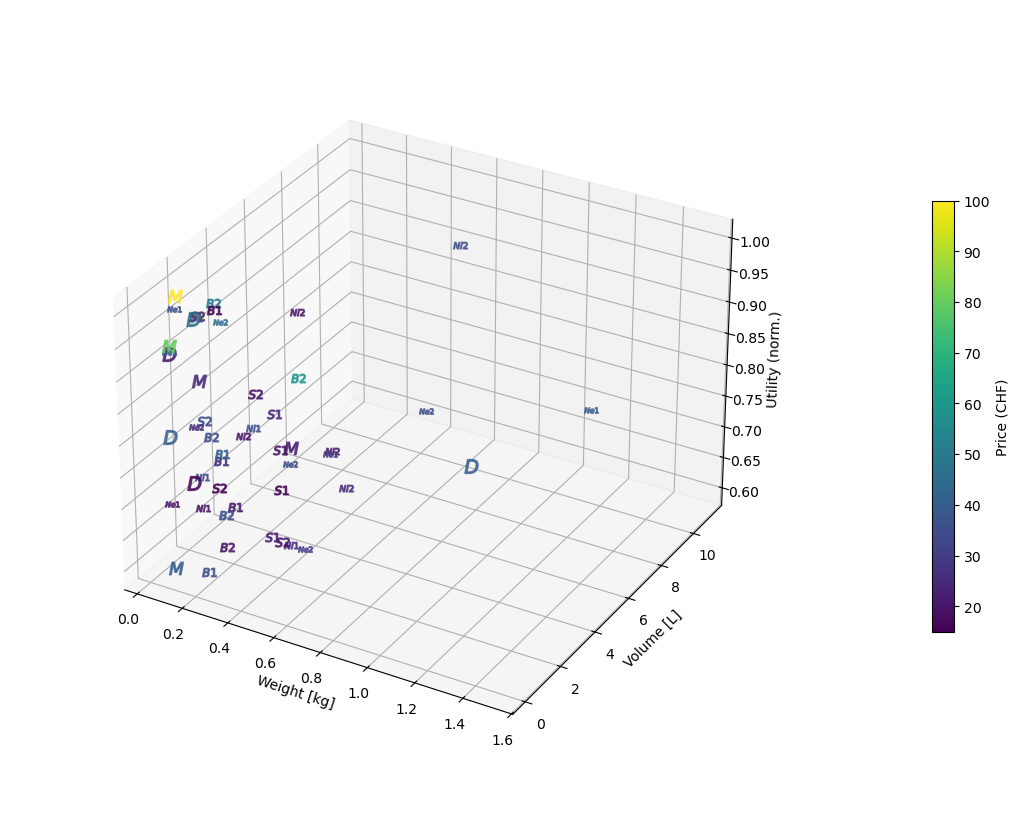

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(14,14))

ax = fig.add_subplot(projection='3d')

x = presents.Weight_kg.values
y = presents.Volume_L.values
z = presents.Utility_N.values
c = presents.Price_CHF.values

ax.set_xlabel('Weight [kg]')
ax.set_ylabel('Volume [L]')
ax.set_zlabel('Utility (norm.)')

# 1. Create a Normalizer based on the full range of prices
norm = mcolors.Normalize(vmin=presents.Price_CHF.min(), vmax=presents.Price_CHF.max())
colormap = cm.viridis # or 'RdYlGn', etc.

#ax.scatter(x, y, z, c=c, marker=presents.Marker.values)
for xi,yi,zi,ci,mi in zip(x, y, z, c, presents.Marker.values):
    color_rgba = colormap(norm(ci))
    ax.scatter(xi, yi, zi, c=[color_rgba], s=100, alpha=0.75, marker=mi)

"""
# Create a grid for the x=8 plane
y_range = np.linspace(presents.Volume_L.min(), presents.Volume_L.max(), 10)
z_range = np.linspace(presents.Utility_N.min(), presents.Utility_N.max(), 10)
Y_plane, Z_plane = np.meshgrid(y_range, z_range)
X_plane = np.full_like(Y_plane, 5)  # constant x=5

# Replace your ax.plot_surface line with this:
ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.2, color='lightblue', zorder=0)
"""

mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
mappable.set_array(presents.Price_CHF) # Link it to your price data

# Add it to the figure
cbar = fig.colorbar(mappable, ax=ax, pad=0.1, shrink=0.4)
cbar.set_label('Price (CHF)')

ax.set_box_aspect(None, zoom=0.85)
#ax.view_init(elev=10, azim=45)
#ax.view_init(elev=100, azim=10)
#ax.dist=11
plt.show()

It seems that over years I learned to pick presents with small weight, but in varying volume. It also looks like the prices are mostly acceptable, with a few outliers (when I remember how happy my mum with "No 5", the highest utility was definitely justified). 

Let's try with the naive approach first: generate all the possible combinations of one present per person (actually the row index in the table of presents):

In [6]:
%%time
combinations = []
for p in presents.Person.unique():
    if len(combinations) == 0:
        for index, row in presents[presents.Person == p].iterrows():
            combinations.append([index])
    else:
        stack_per_person = []
        while len(combinations) > 0:
            c = combinations.pop()
            for index, row in presents[presents.Person == p].iterrows():
                stack_per_present = []
                stack_per_present.extend(c)
                stack_per_present.append(index)
                stack_per_person.append(stack_per_present)
        combinations.extend(stack_per_person)    

CPU times: user 5min 6s, sys: 1.45 s, total: 5min 7s
Wall time: 5min 7s


This took over 5 minuntes, even though it has been run on a MacBook Pro with Apple M3 Max. Since there are 5 presents per person, the expected number of combinations is $5^n = 9\,765\,625$ ($n=10$). Let's verify:

In [7]:
len(combinations)

9765625

Now let's check which presents combination results in the highest total utility, for the moment without taking the dimension limits into account:

In [8]:
%%time
max_utility = 0
c_max = []
for c in combinations:
    current_utility = sum(presents.loc[c].Utility_N)
    if current_utility > max_utility:
        c_max = []
        c_max.append(c)
        max_utility = current_utility
    elif current_utility == max_utility:
        c_max.append(c)

CPU times: user 11min 30s, sys: 2.99 s, total: 11min 33s
Wall time: 11min 33s


This took over 11 minutes! So, clearly this is a naive approach, especially if it needs to be run more than once: imagine trying boundaries or introducing weights to prioritize the youngest niece and nephew and iterating all over!

Let's see the results. Here are the combination of presents that yields the maximum utility (note that there can be multiple solutions in the general case):

In [9]:
c_max

[[0, 8, 12, 15, 20, 27, 30, 38, 40, 46]]

And the utility is:

In [10]:
max_utility

10.0

So, this gives the following combination of presents:

In [11]:
presents.loc[c_max[0]]

,Person,Present,Utility,Volume_L,Weight_kg,Price_CHF,Utility_N,Marker
0,Mum,Perfume,10.0,1.12,0.05,100,1.0,$M$
8,Dad,Powerbank,8.0,0.30,0.20,45,1.0,$D$
12,Brother 1,Lindt Lindor,10.0,1.00,0.23,15,1.0,$B1$
15,Sister-in-law 1,L'Oreal Cream,8.0,0.40,0.20,32,1.0,$S1$
20,Niece 1,Kindle,10.0,0.50,0.20,100,1.0,$Ni1$
27,Nephew 1,Perfume,8.5,0.50,0.10,35,1.0,$Ne1$
30,Nephew 2,Ninteno Joycons,9.0,0.50,0.30,45,1.0,$Ne2$
38,Brother 2,GameCube Controller,10.0,1.30,0.20,50,1.0,$B2$
40,Sister-in-law 2,Wooden Puzzle,9.0,0.50,0.20,25,1.0,$S2$
46,Niece 2,Bunny,10.0,2.00,0.50,20,1.0,$Ni2$


In order to see which limits would be applicable, let's see what are the requirement of the optimal combination of presents:

In [12]:
sum(presents.loc[c_max[0]].Volume_L), sum(presents.loc[c_max[0]].Weight_kg), sum(presents.loc[c_max[0]].Price_CHF)

(8.120000000000001, 2.18, 467)

So, in order to fit the combination that yields the maximum total utility, we need 8.12 L, 2.18 kg and 467 CHF.Let's examine the minimun and maximum bounds for all the resource dimensions.

Let's look a bit further and determine the minimun and maximum bounds for all the resource dimensions.

The minimum and maximum required volume in liters, obtained by picking either the smallest or the biggest present for each family member:

In [13]:
(sum(presents.groupby("Person").Volume_L.min()), sum(presents.groupby("Person").Volume_L.max()))

(4.5, 28.6)

Similarly, the minimum and the maximum weight in kilos:

In [14]:
(sum(presents.groupby("Person").Weight_kg.min()), sum(presents.groupby("Person").Weight_kg.max()))

(1.75, 7.3)

Finally, the minimum and the maximum price in CHF for present combinations:

In [15]:
(sum(presents.groupby("Person").Price_CHF.min()), sum(presents.groupby("Person").Price_CHF.max()))

(187, 532)

Now, let's do it the right way and use the MILP solver:

In [23]:
import numpy as np
from scipy.optimize import milp, Bounds, LinearConstraint

def solve(presents, limits):
    # Define the Data for the solver
    profits = presents.Utility_N
    res_volume = presents.Volume_L
    res_weight = presents.Weight_kg
    res_price = presents.Price_CHF
    
    n_items = len(profits)
    n_groups = len(presents.Person.unique())
    
    # Objective Function (SciPy minimizes, so we negate profits)
    c = -np.array(profits)
    
    # Resource Constraints (A_ub * x <= b_ub)
    A_ub = np.array([res_volume, res_weight, res_price])
    b_ub = np.array(limits)
    
    # Group Constraints (Pick exactly one per group: A_eq * x = 1)
    A_eq = np.zeros((n_groups, n_items))
    current_idx = 0
    groups = presents.groupby("Person", sort=False).Utility_N.apply(list)
    for i, group in enumerate(groups):
        for _ in range(len(group)):
            A_eq[i, current_idx] = 1
            current_idx += 1
    b_eq = np.ones(n_groups)
    
    # Define Constraints for milp
    constraints = [
        LinearConstraint(A_ub, -np.inf, b_ub), # Resource limits
        LinearConstraint(A_eq, b_eq, b_eq)      # Exactly one per group
    ]
    
    # Set variables to binary (0 or 1)
    bounds = Bounds(0, 1)
    integrality = np.ones(n_items) # 1 means integer (binary since bounds are 0-1)
    
    # Solve
    res = milp(c=c, constraints=constraints, bounds=bounds, integrality=integrality)

    if res.success:
        print(f"Optimal Profit: {-res.fun}")
        print(f"Items Selected (Binary Vector): {res.x}")
        print(res)
    else:
        print("No solution found.")

    return res

In [24]:
%%time
res = solve(presents, [9,3,500])

Optimal Profit: 10.0
Items Selected (Binary Vector): [ 1.  0.  0.  0. -0.  0. -0.  0.  1.  0. -0.  0.  1.  0.  0.  1. -0.  0.
  0.  0.  1. -0.  0.  0.  0. -0.  0.  1.  0.  0.  1.  0.  0.  0. -0.  0.
  0. -0.  1.  0.  1. -0.  0.  0.  0.  0.  1.  0.  0.  0.]
        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -10.0
              x: [ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
 mip_node_count: 1
 mip_dual_bound: -10.0
        mip_gap: 0.0
CPU times: user 11.1 ms, sys: 4.43 ms, total: 15.6 ms
Wall time: 9.53 ms


The SciPy implementation not only manages to find the optimal solution, but it also performs the calculation within milliseconds - considerably less than 16 min, which was the total time to genereate all combinations and test the best one. While the naive approach could have been improved, e.g., by introducing some pruning logic, it would be very hard to compete with performance of a dedicated library.

Let's have a look at selected combination of presents:

In [18]:
presents[np.array(res.x).astype(bool)]

,Person,Present,Utility,Volume_L,Weight_kg,Price_CHF,Utility_N,Marker
0,Mum,Perfume,10.0,1.12,0.05,100,1.0,$M$
8,Dad,Powerbank,8.0,0.30,0.20,45,1.0,$D$
12,Brother 1,Lindt Lindor,10.0,1.00,0.23,15,1.0,$B1$
15,Sister-in-law 1,L'Oreal Cream,8.0,0.40,0.20,32,1.0,$S1$
20,Niece 1,Kindle,10.0,0.50,0.20,100,1.0,$Ni1$
27,Nephew 1,Perfume,8.5,0.50,0.10,35,1.0,$Ne1$
30,Nephew 2,Ninteno Joycons,9.0,0.50,0.30,45,1.0,$Ne2$
38,Brother 2,GameCube Controller,10.0,1.30,0.20,50,1.0,$B2$
40,Sister-in-law 2,Wooden Puzzle,9.0,0.50,0.20,25,1.0,$S2$
46,Niece 2,Bunny,10.0,2.00,0.50,20,1.0,$Ni2$


We can not that it's the same as the one found by the dummy, exhaustive search algorithm.

Now let's try with some stricter limits (5 liters, 2 kilos, 400 CHF) and see if we still find a solution:

In [25]:
res = solve(presents, [5,2,400])

Optimal Profit: 8.970833333333333
Items Selected (Binary Vector): [ 0.  0.  0.  0.  1.  0.  1. -0.  0.  0.  1.  0.  0.  0.  0.  1.  0.  0.
  0.  0.  1.  0. -0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  1.  0. -0.
  0. -0.  0.  1.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.]
        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -8.970833333333333
              x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
 mip_node_count: 1
 mip_dual_bound: -8.970833333333333
        mip_gap: 0.0


Finally, let's try to be greedy and lower the limits even further (4 liters, 2 kilos, 300 CHF):

In [20]:
res = solve(presents, [4,2,300])

No solution found.


We can note that a properly implemented solver enables flexible boundaries testing and exploration of solution space. 

In [21]:
presents.Volume_L.min(), presents.Volume_L.max()

(0.1, 11.0)

I also tried solving the problem with different chatbots, using the following prompt "_Given the following table of presents for my family, pick the combination of one present per person such that the total Utility_N is maximal, but total Volume_L is not over 5, total Weight_kg is not over 3 kg and total Price_CHF is not over 400_", followed by the table. To my great surprise, Le Chat couldn't handle it, although it worked with some more relaxed resource limitations. On the other hand, ChatGPT, Gemini, and Claude all provided the optimal soultion. While ChatGPT didn't go into details on how it found the solution, Gemini and Claude specified that they ran the exhaustive search. Moreover, Claude even first tried to use the PuLP solver, but failed to install the dependency. 

Apart from picking the best presents for my family and network resource allocation, applications of the MMKP problem are numerous, just to name a few from [here](https://doi.org/10.1016/j.asoc.2013.01.014): "nurse scheduling, capital budgeting with bounded multiple-choice constraints, service level agreement management in telecommunication networks, strike force asset allocation management, resource allocation, warehouses planning in supply chain management, employee timetabling, open-pit mine production scheduling in the mining industry, and project selection in the engineering-procurement-construction industry".

With all these applications and chatbots which cannot solve the problem efficiently (yet!), a human insight with data exploration, plotting and chosing the right algorithm remains invaluable. 